In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt 

In [ ]:

MATRIZ = np.array([
    [2, 3, 1, 3, 1, 2],
    [3, 3, 2, 1, 2, 3],
    [1, 2, 3, 2, 3, 1],
    [3, 1, 2, 4, 3, 3],
    [1, 2, 3, 2, 3, 1],
    [2, 3, 1, 1, 2, 3]
])


numberToLetter = {
    1: "C",
    2: "Q",
    3: "T",
    4: "E"
}

 
arestas = []

visitados = set()

direcoes = [
    (-1,  0),
    (-1,  1),
    ( 0,  1),
    ( 1,  1),
    ( 1,  0),
    ( 1, -1),
    ( 0, -1),
    (-1, -1)
]

In [3]:
#Criando o grafo
G = nx.DiGraph()

In [4]:
#Construindo o grafo com matriz inicializada 

pos = {(linha, coluna): (coluna, -linha)
        for linha in range(MATRIZ.shape[0])
        for coluna in range(MATRIZ.shape[1])
       }

for linha in range(MATRIZ.shape[0]):
    for coluna in range(MATRIZ.shape[1]):

        node = (linha, coluna)

        G.add_node(
            node,
            tipo=numberToLetter[MATRIZ[linha][coluna]]
        )


In [5]:


quadrados_encontrados = set()

for linha in range(MATRIZ.shape[0]):
    for coluna in range(MATRIZ.shape[1]):

        if MATRIZ[linha][coluna] == 1:

            circulo = (linha, coluna)
            visitados.add(circulo)

            for dl, dc in direcoes:

                nova_linha = linha + dl
                nova_coluna = coluna + dc

                if (
                    0 <= nova_linha < MATRIZ.shape[0]
                    and
                    0 <= nova_coluna < MATRIZ.shape[1]
                ):

                    if MATRIZ[nova_linha][nova_coluna] == 2:

                        quadrado = (nova_linha, nova_coluna)

                        arestas.append(
                            (
                               circulo,
                               quadrado
                            )
                        )

                        quadrados_encontrados.add(quadrado)
                        visitados.add(quadrado)

In [6]:


direcoes_quadrado = [
    (0, 1),  
    (1, 0)   
]

triangulos_encontrados = set()

for linha, coluna in quadrados_encontrados:

    quadrado = (linha, coluna)

    for dl, dc in direcoes_quadrado:

        nova_linha = linha + dl
        nova_coluna = coluna + dc

        if (
            0 <= nova_linha < MATRIZ.shape[0]
            and
            0 <= nova_coluna < MATRIZ.shape[1]
        ):

            if MATRIZ[nova_linha][nova_coluna] == 3:

                triangulo = (nova_linha, nova_coluna)

                arestas.append(
                    (
                       quadrado,
                       triangulo
                    )
                )

                triangulos_encontrados.add(triangulo)
                visitados.add(triangulo)


In [7]:


estrela = None

for linha in range(MATRIZ.shape[0]):
    for coluna in range(MATRIZ.shape[1]):

        if MATRIZ[linha][coluna] == 4:
            estrela = (linha, coluna)


In [8]:


for linha, coluna in triangulos_encontrados:

    triangulo = (linha, coluna)

    for dl, dc in direcoes:

        nova_linha = linha + dl
        nova_coluna = coluna + dc

        if (nova_linha, nova_coluna) == estrela:

            arestas.append(
                (
                    triangulo,
                    estrela
                )
            )

            break

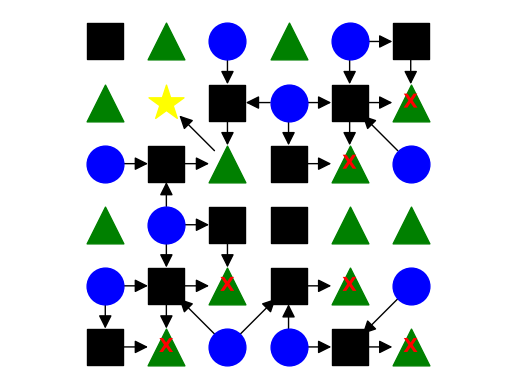

In [9]:


G.add_edges_from(arestas)

x_nodes = set()

for node in visitados:

    if node != estrela and G.out_degree(node) == 0:
        x_nodes.add(node)


labels_x = {
    node: "X"
    for node in x_nodes
}



nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=20,
    node_size=700
)


formatos = {
    "C": ("o", "blue"),
    "Q": ("s", "black"),
    "T": ("^", "green"),
    "E": ("*", "yellow")
}


for tipo, (forma, cor) in formatos.items():

    nodes = [
        node
        for node in G.nodes
        if G.nodes[node]["tipo"] == tipo
    ]

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodes,
        node_shape=forma,
        node_color=cor,
        node_size=700
    )

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels_x,
    font_color="red",
    font_size=14,
    font_weight="bold"
)


plt.axis("off")
plt.axis("equal")
plt.show()